In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, append = True)
import time

import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import numpy as np 

from tenpy.models.model import CouplingMPOModel, NearestNeighborModel
from tenpy.models.lattice import Chain
from tenpy.networks.site import SpinHalfSite, SpinHalfFermionSite, set_common_charges, GroupedSite

#from fisher_lg.Kondo import KondoChain, KondoModel
#from fisher_lg.State import State_Evo

from tenpy.networks.mps import MPS
from tenpy.models.tf_ising import TFIChain
from tenpy.algorithms import dmrg, tebd
from tenpy.networks.mpo import MPO


The bellow is a class constructed for the TFIM which is featured on the TeNPy website

In [129]:


class KondoModel(CouplingMPOModel):
    r"""1D Kondo lattice model with conduction electrons and localized spins.
    
    H = -t \sum_{<ij>\sigma} c^\dagger_{i\sigma} c_{j\sigma} + h.c.
         J_1 \sum_{i \sigma\sigma'} c^\dagger_{i\sigma} \vec{S}_{\sigma\sigma'} c_{i\sigma'} \cdot \vec{s}_i
         J_2 \sum_{i} \vec{s}_i \cdot \vec{s}_{i+1}
    """

    def init_sites(self, model_params):
        conserve = model_params.get('conserve', None)
        
        ferm_site = SpinHalfFermionSite(cons_N='N', cons_Sz= conserve )
        spin_site = SpinHalfSite(conserve= conserve)
        set_common_charges([ferm_site, spin_site], new_charges='same')
        
        site = GroupedSite([ferm_site, spin_site], labels = ['e', 'i'] , charges = 'same')
        return site

    
    def init_terms(self, model_params):
        t = model_params.get('t', 1.0)
        J1 = model_params.get('J_ei', 1.0)
        J2 = model_params.get('J_ii', 0.5)

        # Electron hopping
        for u1, u2, dx in self.lat.pairs['nearest_neighbors']:
            self.add_coupling(-1.0 * t, u1, 'Cdue', u2, 'Cue', dx, plus_hc=True)
            self.add_coupling(-1.0 * t, u1, 'Cdde', u2, 'Cde', dx, plus_hc=True)
        # J1: Kondo coupling on each site
        # S_electron · s_impurity = S^z_e S^z_i + (S^+_e S^-_i + S^-_e S^+_i)/2
        for u in range(len(self.lat.unit_cell)):
            # Sz Sz coupling
            self.add_onsite_term(4.0 * J1, u, "Szi Sze")
            # S+ S- coupling
            self.add_onsite_term(2.0 * J1, u, "Spi Sme", plus_hc = False)  
            self.add_onsite_term(2.0 * J1, u, "Smi Spe", plus_hc = False)     
        
        # J2: Impurity-impurity Heisenberg coupling
        for u1, u2, dx in self.lat.pairs['nearest_neighbors']:
            self.add_coupling(4.0 * J2, u1, 'Szi', u2, 'Szi', dx)
            self.add_coupling(2.0 * J2, u1, 'Spi', u2, 'Smi', dx)
            self.add_coupling(2.0 * J2, u1, 'Smi', u2, 'Spi', dx)


class KondoChain(KondoModel, NearestNeighborModel):
    """The :class:`KondoModel` on a Chain, suitable for TEBD.

    See the :class:`KondoModel` for the documentation of parameters.
    """

    default_lattice = Chain
    force_default_lattice = True


In [185]:
class State_Evo(MPS):
    '''State_Evo is a class copied from tenpy.networks.mps.MPS which contains functions 
    useful for calculating the relevant features of the ground sates of quantum chains.
    '''

    model_dict = {"Ising" : TFIChain, "Kondo" : KondoChain}

    def __init__(self,
                 sites,
                 Bs,
                 SVs,
                 bc='finite',
                 form='B',
                 norm=1.0,
                 unit_cell_width=None,
                 understood_shift_symmetry=False):

        super().__init__(
            sites,
            Bs,
            SVs,
            bc,
            form,
            norm,
            unit_cell_width,
            understood_shift_symmetry=understood_shift_symmetry,
        )

        self.model = None
        self.energy = None
        self.params = None
        
    @classmethod
    def from_dmrg(cls, model_params, dmrg_params=None, Q_model = None):
        '''Otputs State class as the ground state of a dmrg'''

        model_type = model_params.get("model_type", None)
        model_dict = cls.model_dict
        
        if Q_model is None: 
            if model_params is None:
                raise ValueError("Provide model_params")
            model_params = dict(model_params)
            
            try:
                model = model_dict[model_type](model_params)
            except:
                raise KeyError(f"Unsupported model_type: {model_type}")
        else: 
            model = Q_model
            model_params = dict(model_params)

        if dmrg_params is None:
            dmrg_params = {'mixer': None,  # setting this to True helps to escape local minima
                'max_E_err': 1.e-10,
                'trunc_params': {
                    'chi_max': 100,
                    'svd_min': 1.e-10,
                },
                'verbose': False,
                'combine': True,
                'N_times' : 4,  #Only even N_times are used for K,
                'dt': 0.02,'N_steps': 2,
                'order': 2,
                'start_time' : 0  ,
                't_max' : 3,  #only an option for calculating the maximum of the LG correlator
                'check_after' : 5  #""        ""
            }

        assert dmrg_params['N_times'] %2 ==0

        #run dmrg
        psi_temp = cls.set_initial_state(model_params)
        eng = dmrg.TwoSiteDMRGEngine(psi_temp, model, dmrg_params)
        energy, psi_temp = eng.run()

        obj = cls(
            psi_temp.sites,
            [B.copy() for B in psi_temp._B],
            [S.copy() if S is not None else None for S in psi_temp._S],
            psi_temp.bc,
            psi_temp.form,
            psi_temp.norm,
            psi_temp.unit_cell_width,
        )

        obj.energy = energy
        obj.model = model
        obj.model_params = dict(model_params)
        obj.extra_params = dict(dmrg_params)
        obj.model_type = dict(model_params).get("model_type", None)

        return obj
    
    @classmethod
    def from_MPS(cls, psi):
        obj = cls(
        psi.sites,
        [B.copy() for B in psi._B],
        [S.copy() if S is not None else None for S in psi._S],
        psi.bc,
        psi.form,
        psi.norm,
        psi.unit_cell_width,
        )

        obj.energy = None
        obj.model = None
        obj.model_params = None
        obj.extra_params = None
        obj.model_type = None

        return obj
    
    @classmethod
    def from_dmrg_search_Sz(cls, model_params, dmrg_params=None):

        model_type = model_params["model_type"]
        conserve = model_params.get('conserve'  , None )
        
        if model_type != "Kondo":
            raise ValueError("Sz search currently implemented only for Kondo.")
        if conserve is None:
            raise ValueError("conserve must be not None for specialized sector algorithm")
        
        model = cls.model_dict[model_type](dict(model_params))
        L = len(model.lat.mps_sites())

        best_energy = np.inf
        best_psi = None
        best_Sz = None

        for target_Sz in range(0 , L + 1 , 2):
            
            psi_temp = cls._initial_state_kondo(model, target_Sz)
            eng = dmrg.TwoSiteDMRGEngine( psi_temp, model, dmrg_params )

            energy, psi_temp = eng.run()

            if energy < best_energy:
                best_energy = energy
                best_psi = psi_temp.copy()
                best_Sz = target_Sz
            else: 
                break
        neighbor_list = [1]
        if best_Sz != 0:
            neighbor_list.append(-1)
            
        for i in neighbor_list:

            psi_temp = cls._initial_state_kondo(model, best_Sz + i)
            eng = dmrg.TwoSiteDMRGEngine( psi_temp, model, dmrg_params )
            energy, psi_temp = eng.run()
            if energy < best_energy:
                best_energy = energy
                best_psi =psi_temp.copy()
                best_Sz = target_Sz

        obj = cls(
            best_psi.sites,
            [B.copy() for B in best_psi._B],
            [None if S is None else S.copy() for S in best_psi._S],
            best_psi.bc,
            best_psi.form,
            best_psi.norm,
            best_psi.unit_cell_width,
        )

        obj.energy = best_energy
        obj.model = model
        obj.model_params = dict(model_params)
        obj.extra_params = dict(dmrg_params)
        obj.model_type = model_type
        obj.best_Sz = best_Sz

        return obj
    
    @staticmethod
    def _initial_state_kondo(model, target_Sz):
        """
        Construct a half-filled product state with total Sz = target_Sz.
        """
        chain = model.lat.mps_sites()
        L = len(chain)

        # reference state has total Sz = 0
        state = ["up_e down_i"] * L

        if target_Sz > 0:
            if target_Sz > L:
                raise ValueError("Requested Sz sector impossible.")

            for i in range(target_Sz):
                state[i] = "up_e up_i"

        elif target_Sz < 0:
            if -target_Sz > L:
                raise ValueError("Requested Sz sector impossible.")

            for i in range(-target_Sz):
                state[i] = "down_e down_i"

        return MPS.from_product_state(chain, state)
    
    @staticmethod
    def set_initial_state(model_params):
        '''Returns an initial state suitable for the given model which is compatible with DMRG'''
        model_type = model_params.get('model_type', None)
        model_dict = State_Evo.model_dict
        
        if model_type is not None:
            model = model_dict[model_type](model_params)
            if model_type == 'Ising':
                return MPS.from_lat_product_state(model.lat, [['up']])
            if model_type == "Kondo":
                L = model_params['L']
                state = ["up_e up_i"] * L   # electron site, impurity site
                chain = model.lat.mps_sites()
                return MPS.from_product_state(chain, state)
                
        else:
            raise ValueError(f'Select model which has been configured. Available models are: {model_dict}')

    
    @property
    def available_models(self):
        """List of model types which have been included manually. 
        from_dmrg has the option of supplying a preconfigured model along with its
        parameters"""
        return self.__class__.model_dict

    
    def set_model(self, model_params = None):
        '''sets self.model and self.model_params and self.model_type and returns the dictionary'''
        
        model_dict = self.available_models
        if model_params is None:
            raise ValueError("Provide model_params")
        model_params = dict(model_params)
        model_type = model_params.get("model_type", "None")
        try:
            model = model_dict[model_type](model_params)
        except:
            raise KeyError(f"Unsupported model_type: {model_type}")
        
        self.model = model
        self.model_params = model_params
        self.model_type = model_type

        return model_params

    def set_extra_params(self, extra_params = None):
        '''Sets self.extra_params and returns the dictionary'''

        if extra_params is None:
            raise ValueError("Provide extra_params")
        self.extra_params = dict(extra_params)

        return dict(extra_params)

    def set_energy(self, E0 = None):
        '''sets and returns the GS energy assuming the model, model_params, and extra_params properties
            have already been specified'''
        if E0 is None:
            if self.model_params is None:
                raise ValueError ('Provide either E0 or use .set_model(model_params) to set the model')
            #run dmrg
            psi_temp = MPS.from_lat_product_state(self.model.lat, [['up']])
            eng = dmrg.TwoSiteDMRGEngine(psi_temp, self.model, self.extra_params)
            energy, psi_temp = eng.run()
            self.energy = energy
        elif E0 in float:
            self.energy = E0
        else:
            raise ValueError("E0 must be float or None")
        
        return self.energy     

    def get_state_labels(self):     
        """Returns the state labels of the model corresponding to model_type"""  
        
        return self.model.init_sites(self.model_params).state_labels    #for fiding the names of the initial states
            
    def get_opnames(self):     
        """Returns the state labels of the model corresponding to model_type"""  
        
        return self.model.unit_cell[0].opnames    #for fiding the names of the initial states
            


    def QFI(self, op, op_sum = True):
        """
        Calculate the Quantum Fisher Information (QFI) for a given state and operator.
        
        Parameters:
        psi : MPS
            The matrix product state representing the quantum state.
        op : str
            The operator for which to calculate the QFI ('Sigmax' or 'Sigmaz').
            
        Returns:
        float
            The calculated QFI value.
        """
        L_half = self.L//2
        if op_sum: 
            # Calculate the expectation value of the operator
            expe = np.mean(self.expectation_value(op))

            # Calculate the correlation function
            corr_q2 = self.correlation_function(op, op, sites1=None, sites2=None)
            # Calculate the expectation value of the squared operator
            expectation_q2 = np.mean(corr_q2)
        else:
            expe = self.expectation_value(op)[L_half]
            expectation_q2 = self.correlation_function(op, op, sites1=[L_half], sites2=[L_half])
        
        # Calculate QFI using the formula: QFI = 4 * (expectation_q2 - expe^2)
        qfi = 4 * (expectation_q2 - expe**2).flatten()[0]
        
        return qfi

        
    
    def apply_Q_MPO(self, op, op_sum = True):
        phi = self.copy()
        model = self.model
        model_params = self.model_params
        extra_params = self.extra_params
        mpo = build_Q_MPO( op = op, op_sum = op_sum, model = model)
        mpo.apply(phi, options={'compression_method' : 'SVD'})

        phi = State_Evo.from_MPS(phi)
        phi.set_model(model_params = model_params)
        phi.set_extra_params(extra_params = extra_params)
        return  phi
    

    def TEBD_initialize(self, model_params = None , dmrg_params = None):
        """Initialize the TEBD engine with appropriate start time"""
        
        phi_t = self.copy()

        if self.model != None:
            model = self.model 
        else:
            model = self.get_model(model_params)
        if self.extra_params != None:
            extra_params = self.extra_params
        else:
            extra_params = self.get_extra_params(dmrg_params)
        
        dt = extra_params.get('dt', 0.05)
        start_time = extra_params.get('start_time',0)

        engine = tebd.TEBDEngine(phi_t, model, extra_params)
        engine.evolved_time = 0

        if start_time > 0 and start_time < dt:
            engine.calc_U(2, start_time)
            engine.evolve( 1,   dt = start_time)
            engine.evolved_time = round(engine.evolved_time, 4)
        elif start_time >0:
            initial_steps = round(start_time / dt, 1)
            dt_prime = round(start_time/initial_steps, 4)
            engine.calc_U(2, dt_prime )
            engine.evolve(initial_steps,   dt = dt_prime)
            engine.evolved_time = round(engine.evolved_time, 4)
        engine.calc_U(2, dt )

        return phi_t, engine
    


    def calculate_QtQ(self, op, op_sum = True, calc_upto_2t = False ):
        """ Calculates 1/2 < psi | {Q(t), Q} | psi > 
            for psi the ground state of model """
        
        extra_params = self.extra_params.copy()
        model_params = self.model_params.copy()
        E0 = self.energy
        start_time = extra_params.get('start_time',0)
        N_times = extra_params.get('N_times', 10)
        M = self.model

        #DMRG engine
        # apply phi = Q |psi > Must be careful here because some processes
        # in MPS and MPO by default normalize the output wavefunction
        phi = self.apply_Q_MPO( op, op_sum = op_sum)
        
        # TEBD engine
        phi_t, engine = phi.TEBD_initialize()

        times = [engine.evolved_time]
        expec_U = [np.real(phi.overlap(phi_t)* np.exp(1j * E0 * start_time))]  # 1/2 <psi | {Q(t), Q} | psi > = Re[< phi | U | phi > exp(i E_0 t)]
        
        for _ in range(N_times):

            engine.run()
            t = engine.evolved_time
            times.append(round(t, 4))
            expec_U.append(np.real(phi.overlap(phi_t) * np.exp(1j * E0 * t)))
            
        if calc_upto_2t: #option used for calculate_LG_correlator which combines two legs 
                        #of time and expec_U for calculating 2 C(t) - C(2t) easily

            extra_params['N_steps'] = 2 * (extra_params['N_steps'])
            N_times = round( N_times /2)
            engine = tebd.TEBDEngine(phi_t, M, extra_params)
            engine.evolved_time = t
            
            for _ in range(N_times):
                
                engine.run()
                t= engine.evolved_time
                expec = np.real(phi.overlap(phi_t) * np.exp(1j * E0 * t))
                times += [-100, round(t, 4)]
                expec_U += [-100, expec] #so that if the implementation is wrong we will see it in the data
            
        return times, expec_U
    
    def calculate_LG_correlator(self, op, op_sum = True ):
        """Returns  times, 2 [C(t) - C(0)] - [C(2t) - C(0)], 2C(t) - C(2t) """

        #Calculates C values from 0 to time_end
        times, expec_U = self.calculate_QtQ(op, op_sum = op_sum, calc_upto_2t  = True )    #Calculates only the extra C values needed to calculate K

        half_len = len(times)//2 +1
        LG_B_lst = []
        K_lst = []
        # LG_B = 2C(t) - C(2t) - C(0)
        for i in range(half_len):
            LG_B_lst += [expec_U[i] * 2 - expec_U[2 * i] - expec_U[0] ]
            K_lst += [expec_U[i] * 2 - expec_U[2 * i] ]
            
        return times[: half_len] , LG_B_lst, K_lst 


    def calculate_LG_bound(self, op, op_sum = True, return_QFI = False):
        """Calculates the lower bound on the QFI set by the LG correlator QFI > 8 LG_B_Max
        using a "search a little after the first local maximum" algorithm """

        model_params = self.model_params
        extra_params = self.extra_params
        E0 = self.energy
        start_time = extra_params.get('start_time' , 0)

        #Initialize model and phi through building the Q_MPO
        phi = self.apply_Q_MPO( op, op_sum = op_sum)

        #Get QFI
        qfi = None
        if return_QFI:
            qfi = self.QFI( op, op_sum = op_sum)
        
        # TEBD engine
        phi_t, engine = phi.TEBD_initialize()

        #set up the maximum number of steps 
        t_max = extra_params.get('t_max', 5)
        N_steps = extra_params['N_steps']
        dt = extra_params['dt']
        step_max = int(t_max/(N_steps * dt))
        
        LG_B_vals = []
        best_LG_B = -np.inf
        best_t = 0
        i = 0
        i_max = np.inf
        max_iter = 3

        times = [engine.evolved_time]
        expec_U = [np.real(phi.overlap(phi_t)* np.exp(1j * E0 * start_time))]  # 1/2 <psi | {Q(t), Q} | psi > = Re[< phi | U | phi > exp(i E_0 t)]
    
        while i < step_max:     #loop until the end
            #construct the time correlator list
            engine.run()
            t = engine.evolved_time
            expec_U.append(np.real(phi.overlap(phi_t) * np.exp(1j * E0 * t)))
            times.append(t)

            while 2 *i <= len(expec_U)-1:    #when the correlator list is long enough calculate...
                LG_B = 2* expec_U[i] - expec_U[2*i] - expec_U[0]
                LG_B_vals.append(LG_B)
                
                if LG_B > best_LG_B:    #keep track of the largest LG_B value
                    best_LG_B = LG_B

                    # detect first local maximum
                if len(LG_B_vals) >= 3:
                    if (LG_B_vals[-2] > LG_B_vals[-3]) and (LG_B_vals[-2] >= LG_B_vals[-1]) and (LG_B_vals[-2] >= best_LG_B):
                        local_max = LG_B_vals[-2]   #LG_B
                        i_max = i                   #index
                        best_t = times[i]           #time
                        max_iter -= 1               #only let 3 local maximums be found
                        
                if i_max +5 < i:   #check after 10 steps after the maximum
                    if best_LG_B > local_max and max_iter != 0:   #if there is a better LG_B then reset
                        i_max = np.inf
                    else:                       #if nothing beats it then return the last local maximum
                        return best_t, 8 * local_max, qfi
                i += 1

        


def build_Q_MPO( op = 'Sigmax', op_sum = True, model = None, model_params = {}):
    """
    builds an MPO corresponding to Q = 1/L sum_i op_i
    if apply_to_GS then it ftn will return op | GS > as a MPS
    """
    if model is None:
        model_type = model_params.get("model_type", "Ising")
        if model_type == "Ising":
            model = TFIChain(model_params)
        else: 
            raise ValueError("Model type not configured yet")
    L = model.lat.N_cells
    Id = model.lat.unit_cell[0].get_op("Id")
    if op not in model.lat.unit_cell[0].opnames:
        raise ValueError("operator "+ op," is not allowed. Please choose in " + str(model.lat.unit_cell[0].opnames))
    Q = model.lat.unit_cell[0].get_op(op)

    W = []
    for i in range(L):
        if op_sum:
            Wi = np.empty((2, 2), dtype=object)
            Wi[0, 0] = Id
            Wi[1, 1] = Id
            Wi[0, 1] = Q / L
            Wi[1, 0] = None
        else:
            Wi = np.empty((1, 1), dtype=object)
            Wi[0, 0] = Q if i == L//2 else Id
    
        W.append(Wi)

    mpo = MPO.from_grids(model.lat.mps_sites(), W, IdL=0, IdR=1 if op_sum else 0)

    return mpo



In [ ]:
model_params = {
    'J_ei': 1 , 'J_ii': 1,  
    't' : 1,
    'L': 4,
    'bc_MPS': 'finite',
    'model_type' : "Kondo",
    'conserve' : 'Sz'
}

extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-8,
    'max_sweeps'  : 30,
    'max_trunc_err' : 1e-5,
    'trunc_params': {
        'chi_max': 220,
        'svd_min': 1.e-10,
        'trunc_cut': 1e-6
    },
    'verbose': False,
    'combine': True, #tebd params 
    'N_times' : 4,  #Only even N_times are used for K, 
    'dt': 0.02,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : 3  #only an option for calculating the maximum of the LG correlator
}

#psi = State_Evo.from_dmrg_search_Sz(model_params = model_params, dmrg_params = extra_params)
#print(psi.calculate_LG_bound(op = 'Szi', op_sum= False, return_QFI = True))


In [148]:
psiw = State_Evo.from_dmrg_search_Sz(model_params = model_params, dmrg_params = extra_params)

start_time = time.perf_counter()
psi.calculate_QtQ('Sigmazi', op_sum = False)
end_time = time.perf_counter()

print(end_time - start_time, psiw.energy, psi.model_type)


2.6904673999524675 -4.54724215387448 Kondo


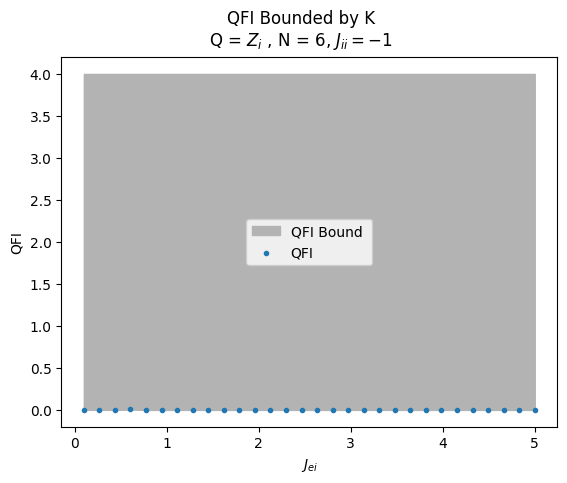

In [274]:
L = 6
chi_max = 250
op = 'Sigmazi'
op_sum = False
num_points = 30
t_end = 10
dt = 0.02

extra_params = {
   'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-8,
    'max_sweeps'  : 30,
    'max_trunc_err' : 1e-6,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': 1.e-10,
        'trunc_cut': 1e-6
    },
    'verbose': False,
    'combine': True,
    'N_times' : 2,  #Only even N_times are used for K,
    'dt': dt,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : t_end,  #only an option for calculating the maximum of the LG correlator
}

theta_range = np.linspace(0.1, 5.0, num_points)

fig, ax = plt.subplots(1)

LG_bound = []
QFI_lst =[]
for theta in theta_range:
    model_params = {
    'J_ei': -1.0 * theta , 'J_ii': -1,  #J_ei =1   J_ii pm,  J_ei=-1   J_ii p
    't' : 1.0,
    'L': L,
    'bc_MPS': 'finite',
    'model_type' : "Kondo",
    'conserve' : None}

    psi = State_Evo.from_dmrg(model_params, extra_params)
    t_max, LG_max , qfi = psi.calculate_LG_bound(op, op_sum = op_sum, return_QFI= True)
    LG_bound += [LG_max]
    QFI_lst += [qfi]

ax.fill_between(theta_range, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range, QFI_lst, marker = '.', label = "QFI", zorder = 3)


fig.suptitle("QFI Bounded by K\nQ = $Z_i$ , N = " + str(L) + ", $J_{ii}= -1$")
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g"))
plt.xlabel("$J_{ei}$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()

In [242]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\Kondo_L4_Zi_QFI_Bound.png")

3.572578902438302


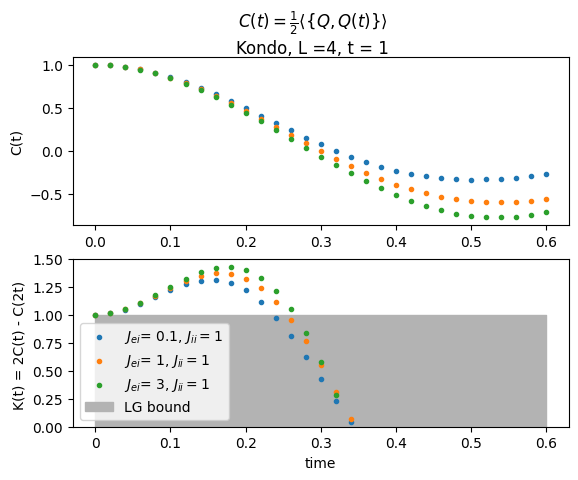

In [263]:
L = 4
chi_max = 220
op = 'Sigmazi'
op_sum = False
num_points = 30
t_end = 1
dt = 0.02
fig, ax = plt.subplots(2)

extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-8,
    'max_sweeps'  : 30,
    'max_trunc_err' : 1e-6,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': 1.e-10,
        'trunc_cut': 1e-7
    },
    'verbose': False,
    'combine': True, #tebd params 
    'N_times' : num_points,
    'dt': dt,'N_steps': max(2*int( t_end//(2*dt * num_points)),1),
    'order': 2, 'start_time' : 0,
    't_max' : 30  #only an option for calculating the maximum of the LG correlator
    }
#[10, -.1], [5, -0.1], [1, -.1] t  = 3
Jg_lst = [  [.1, 1],[1, 1],[3, 1]]

for J_ei, J_ii in Jg_lst: 

    model_params = {
    'J_ei': J_ei , 'J_ii': J_ii,  
    't' : 1.0,
    'L': L,
    'bc_MPS': 'finite',
    'model_type' : "Kondo",
    'conserve' : None}

    psi = State_Evo.from_dmrg(model_params = model_params, dmrg_params = extra_params)
    
    times, Ct = psi.calculate_QtQ(op, op_sum = op_sum)
    ax[0].scatter(times, Ct, marker = '.', label = "$J_{ei} $= " + str(round(J_ei,2)) + ", $J_{ii}$ = " + str(round(J_ii,2)), zorder = 3)
    times, LG_correl, Kt = psi.calculate_LG_correlator(op, op_sum = op_sum)
    #ax[1].scatter(times, LG_correl, marker = '.', label = "$\\J = " + str(round(J_ei,2)) + ", h = " + str(round(J_ii,2)), zorder = 3)
    ax[1].scatter(times, Kt, marker = '.', label= "$J_{ei}$= " + str(round(J_ei,2)) + ", $J_{ii}=$" + str(round(J_ii,2)), zorder= 3)
ax[1].fill_between(times,-3, 1 ,  color = '.7', label = "LG bound "  )

print(psi.QFI(op, op_sum))

fig.suptitle("$C(t) = \\frac{1}{2}\\langle \\{Q, Q(t) \\}\\rangle$\nKondo, L =" + str(L) + ", t = 1")
ax[1].xaxis.set_major_formatter(tck.FormatStrFormatter("%g"))
plt.xlabel("time")
ax[0].set(ylabel = "C(t)")
#ax[1].set(ylabel = "2C(t) - C(2t) - C(0)")
ax[1].set(ylabel = "K(t) = 2C(t) - C(2t) ")
ax[1].set_ylim([0,1.5])
plt.legend()

plt.show()

In [ ]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\Kondo_L10_C_K.png")